In [1]:
from defenders.multi_turn.TCA.statistical_significance_proof.utility import plot_hypothesis_test ,plot_bootstrap_distribution ,plot_box_separation
from defenders.multi_turn.TCA.statistical_significance_proof.statistical_test import simple_two_sample_test, simple_bootstrap_test

In [2]:
import pandas as pd

df = pd.read_csv("../../integrated/data/processed/train(6).csv")

In [3]:
result = simple_two_sample_test(
    df,
    score_col="threat_accel",
    label_col="label"
)

Mean Safe : 6.399100288074498
Mean Attack: 14.81024566364148
Difference : 8.411145375566981
Standard Error: 1.3873440426748345
t-statistic:6.062768222473554
p-value:1.3939251974903755e-09
t-critical: 1.9602377667881852
95% CI : [5.691621187587171, 11.130669563546792]
Decision: REJECT H0


In [4]:
t_stat = result["t_stat"]
p_value = result["p_value"]
ci = result["ci"]
df_t = result["df"]

In [5]:
scores = df["threat_accel"].values
labels = df["label"].values

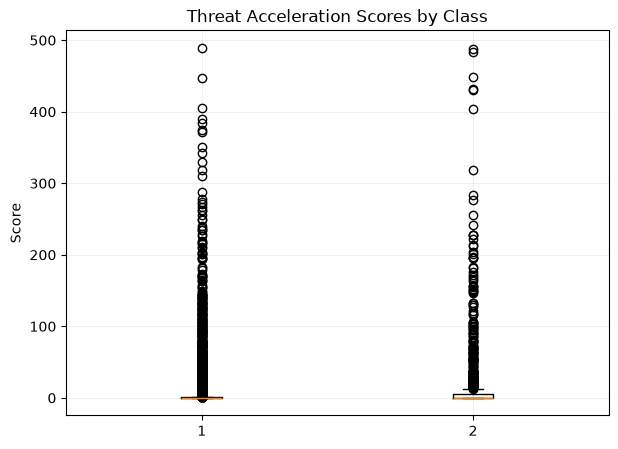

In [6]:
plot_box_separation(
    scores,
    labels,
    class_names=("Safe", "Adversarial"),
    title="Threat Acceleration Scores by Class"
)

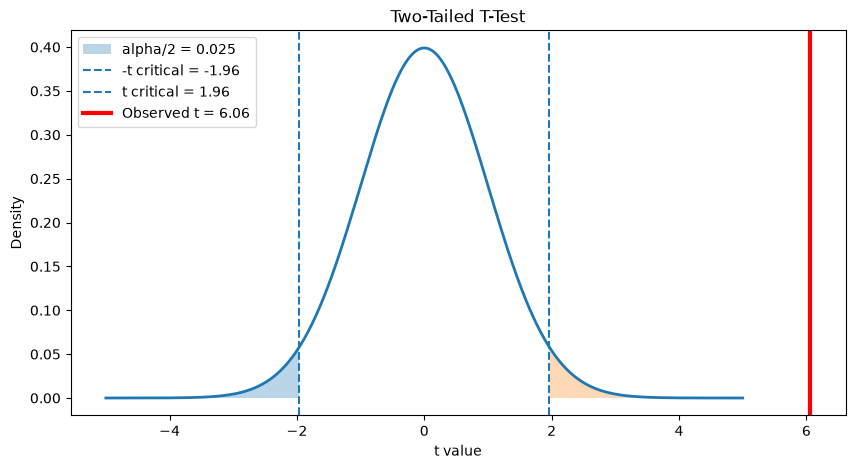

In [7]:
plot_hypothesis_test(
    t_stat=t_stat,
    df=df_t,
    alpha=0.05
)

In [8]:
diff ,ci ,bootstrap_diffs= simple_bootstrap_test(
    df, 
    feature_col="threat_accel",
    label_col="label",
    n_resamples=5000
)

Mean Safe:6.399100288074498
Mean Attack:14.81024566364148
Difference:8.411145375566981
95% CI: [5.825522303641437,11.122570448596537]
Decision: REJECT H0
Conclusion: Significant difference between groups


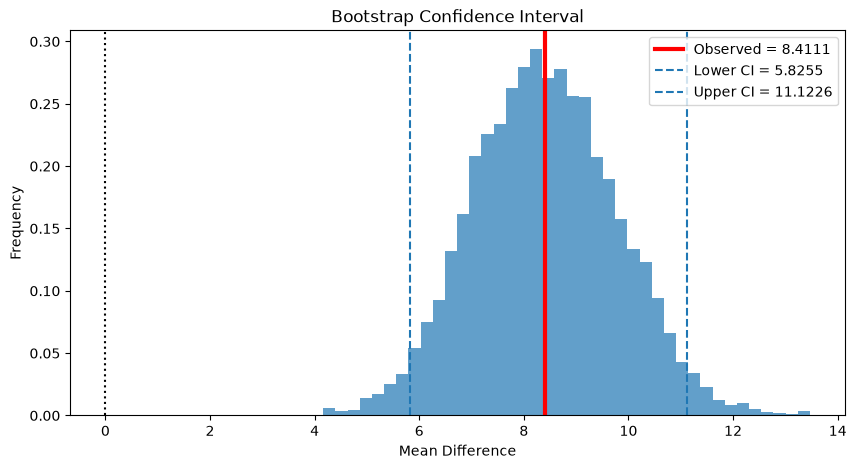

In [9]:
plot_bootstrap_distribution(
    bootstrap_diffs=bootstrap_diffs,
    observed_diff=diff,
    lower=ci[0],
    upper=ci[1]
)

In [10]:
features = df.columns.tolist()
#remove conv_id and turn_id and label
features.remove("conv_id")
features.remove("turn_id")
features.remove("label")
results = []

for feature in features:
    #each feature will see its significance test and bootstrap test
    diff, ci, bootstrap_diffs = simple_bootstrap_test(
        df,
        feature_col=feature,
        label_col="label",
        n_resamples=5000
    )

    significant = not (ci[0] <= 0 <= ci[1])

    results.append({
        "feature": feature,
        "difference": diff,
        "ci_lower": ci[0],
        "ci_upper": ci[1],
        "significant": significant,
        "bootstrap_diffs": bootstrap_diffs
    })

Mean Safe:-0.1849182822299421
Mean Attack:0.35545992987497427
Difference:0.5403782121049163
95% CI: [0.5064939975693091,0.5735531750120959]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.4900457358084477
Mean Attack:0.0
Difference:0.4900457358084477
95% CI: [0.47887745493677697,0.5012106537530266]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.014683280665883014
Mean Attack:0.3127412172937139
Difference:0.32742449795959694
95% CI: [0.2915653224259345,0.3639231662501689]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.07006227969511648
Mean Attack:0.484656396498482
Difference:0.5547186761935985
95% CI: [0.5285605693867036,0.5804462427844181]
Decision: REJECT H0
Conclusion: Significant difference between groups
Mean Safe:-0.8251916435646891
Mean Attack:0.28887518553293
Difference:1.1140668290976192
95% CI: [1.079676664686242,1.148666047223733]
Decision: REJECT H0
Conclusion: Signifi

In [11]:
import pandas as pd

results_df_bootstrap_test = pd.DataFrame(results)

In [12]:
results_df_bootstrap_test["abs_difference"] = results_df_bootstrap_test ["difference"].abs()

results_df_bootstrap_test = results_df_bootstrap_test.sort_values(
    "abs_difference",
    ascending=False
)

In [13]:
print(results_df_bootstrap_test.head(10))

                feature  difference   ci_lower    ci_upper  significant  \
8         toxicity_diff   80.734856  45.227745  119.273050         True   
10       toxicity_accel   77.961448  49.797637  108.945470         True   
11         threat_accel    8.411145   5.825522   11.122570         True   
9           threat_diff    6.115947   3.491674    8.892936         True   
12         risk_slope_3   -3.728763  -4.703208   -2.763626         True   
13  max_toxicity_so_far    1.703858   1.401421    2.000801         True   
5      prev_progressive    1.116446   1.072728    1.158904         True   
4        max_similarity    1.114067   1.079677    1.148666         True   
14    max_threat_so_far    0.732668   0.620631    0.845876         True   
7     pattern_risk_ema3    0.625906   0.594606    0.658969         True   

                                      bootstrap_diffs  abs_difference  
8   [66.29024056087889, 84.37393425040709, 61.5418...       80.734856  
10  [64.57504862663389, 75.002

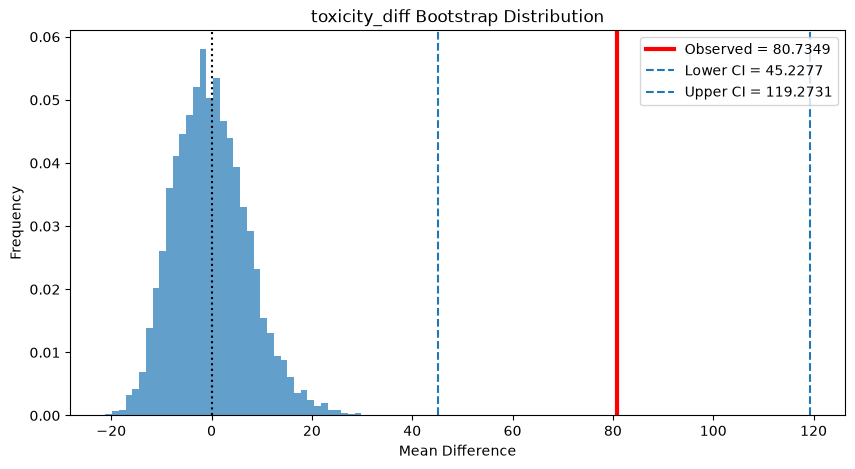

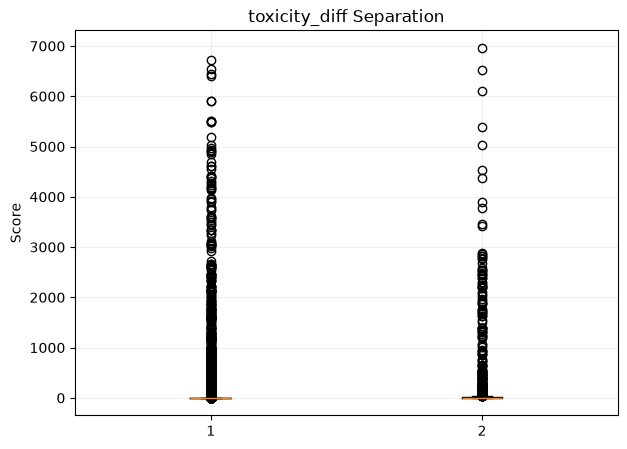

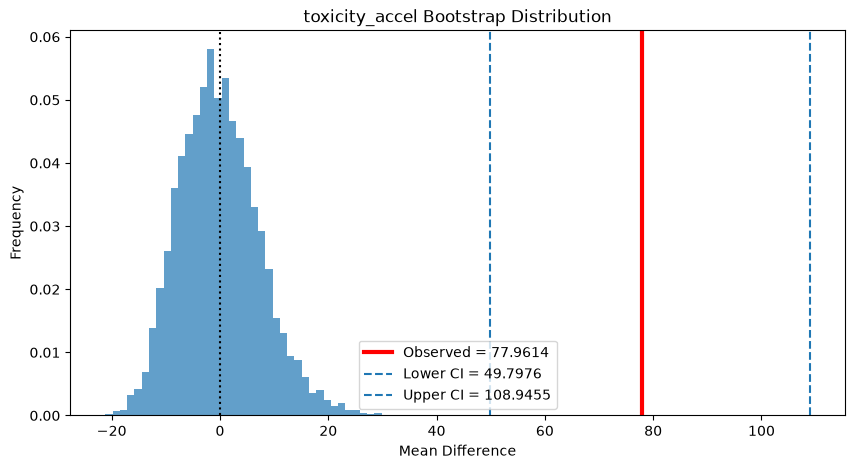

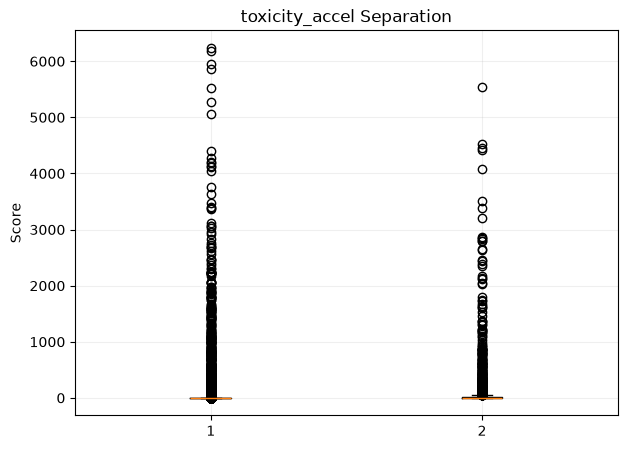

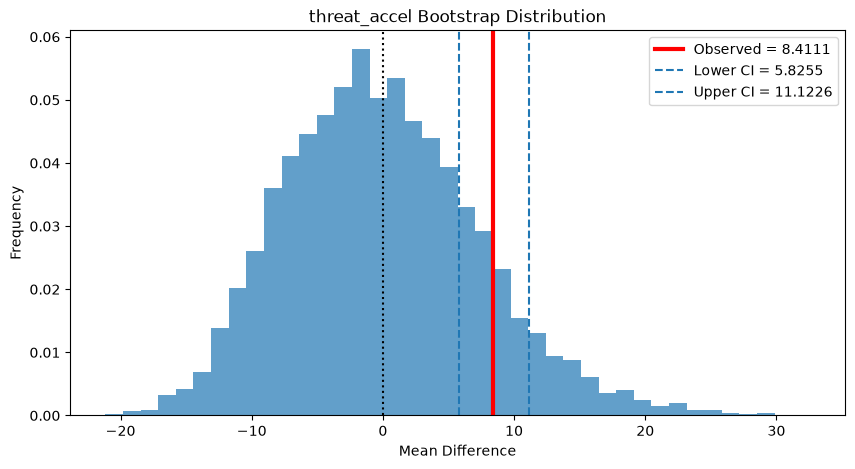

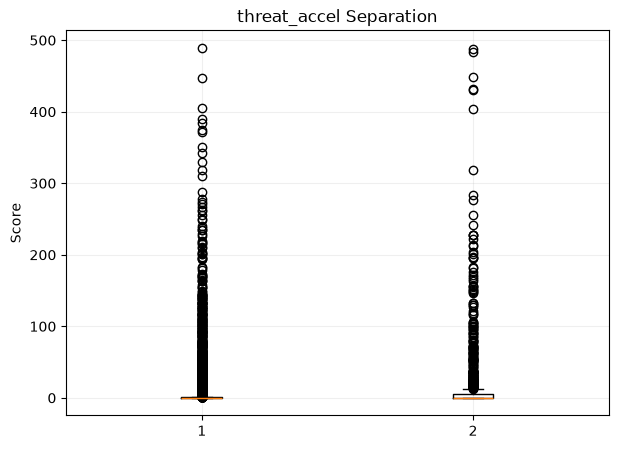

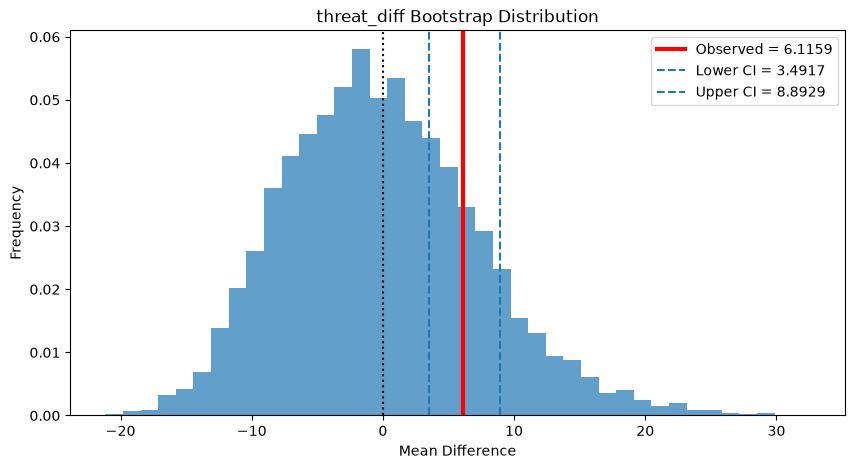

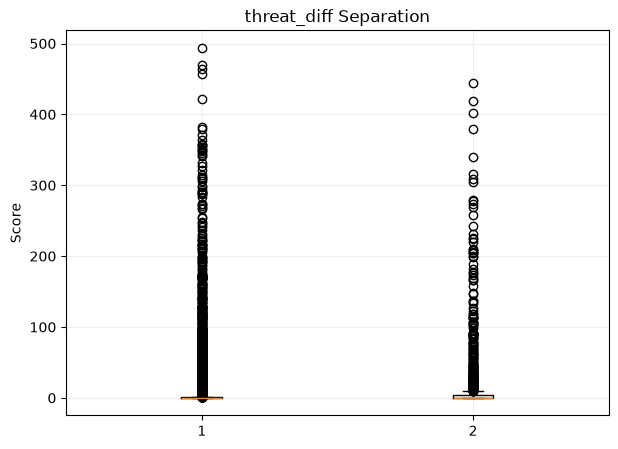

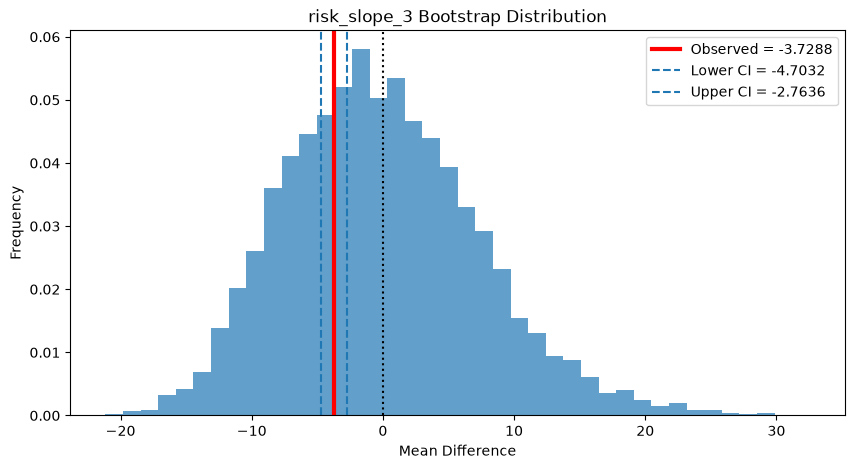

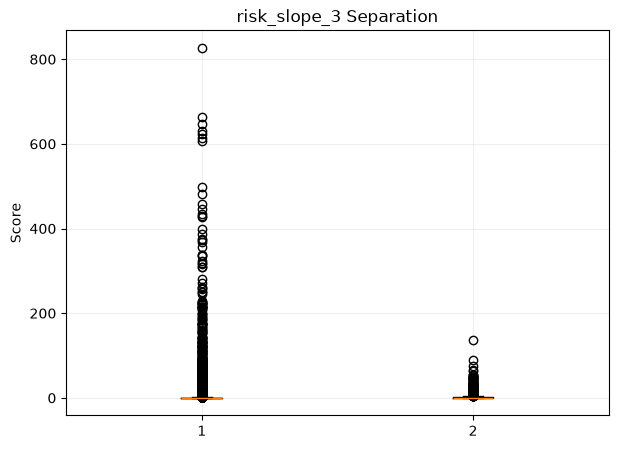

In [14]:
top_features = results_df_bootstrap_test.head(5)["feature"]

for feature in top_features:
    
    row = results_df_bootstrap_test[results_df_bootstrap_test["feature"] == feature].iloc[0]

  
    diff = row["difference"]
    ci_lower = row["ci_lower"]
    ci_upper = row["ci_upper"]

    
    scores = df[feature].values
    labels = df["label"].values

    
    plot_bootstrap_distribution(
        bootstrap_diffs=bootstrap_diffs,  
        observed_diff=diff,
        lower=ci_lower,
        upper=ci_upper,
        title=f"{feature} Bootstrap Distribution"
    )

    plot_box_separation(
        scores,
        labels,
        class_names=("Safe", "Adversarial"),
        title=f"{feature} Separation"
    )

In [15]:
features = df.columns.tolist()
#remove conv_id and turn_id and label
features.remove("conv_id")
features.remove("turn_id")
features.remove("label")
results = []

for feature in features:
    #each feature will see its significance test on two sample test
    result =simple_two_sample_test(
        df,
        score_col=feature,
        label_col="label",
      
        
    )

   
    significant = not (result['ci'][0] <= 0 <= result['ci'][1])

    results.append({
        't_stat': result['t_stat'],
        'p_value': result['p_value'],   
        'ci': result['ci'],
        'df': result['df'],
        'feature': feature,
       
    })

Mean Safe : -0.1849182822299421
Mean Attack: 0.35545992987497427
Difference : 0.5403782121049163
Standard Error: 0.016774552172399728
t-statistic:32.21416622936951
p-value:0.0
t-critical: 1.9602377667881852
95% CI : [0.5074961014156196, 0.573260322794213]
Decision: REJECT H0
Mean Safe : -0.4900457358084477
Mean Attack: 0.0
Difference : 0.4900457358084477
Standard Error: 0.0057983156605560075
t-statistic:84.51518759871321
p-value:0.0
t-critical: 1.9602377667881852
95% CI : [0.4786796584668664, 0.5014118131500289]
Decision: REJECT H0
Mean Safe : -0.014683280665883014
Mean Attack: 0.3127412172937139
Difference : 0.32742449795959694
Standard Error: 0.018391601452751236
t-statistic:17.802935693270847
p-value:0.0
t-critical: 1.9602377667881852
95% CI : [0.2913725862001975, 0.36347640971899636]
Decision: REJECT H0
Mean Safe : -0.07006227969511648
Mean Attack: 0.484656396498482
Difference : 0.5547186761935985
Standard Error: 0.012864376081369965
t-statistic:43.12052700301069
p-value:0.0
t-crit

In [16]:
import pandas as pd

results_df_two_sample = pd.DataFrame(results)

In [17]:

results_df_two_sample = results_df_two_sample.sort_values(
    "p_value",
    ascending=True
)

In [18]:
print(results_df_two_sample.head(10))

       t_stat  p_value                                         ci    df  \
0   32.214166      0.0    (0.5074961014156196, 0.573260322794213)  8666   
1   84.515188      0.0   (0.4786796584668664, 0.5014118131500289)  8666   
2   17.802936      0.0  (0.2913725862001975, 0.36347640971899636)  8666   
3   43.120527      0.0   (0.5295014403527305, 0.5799359120344665)  8666   
4   62.387772      0.0    (1.079062599975472, 1.1490710582197665)  8666   
5   50.300483      0.0   (1.0729373386460073, 1.1599543687787621)  8666   
6   10.255369      0.0  (0.2964581193309055, 0.43657124369561073)  8666   
7   37.900852      0.0   (0.5935336753042301, 0.6582775391238219)  8666   
14  12.963584      0.0   (0.6218802854083253, 0.8434552814801674)  8666   
13  11.123118      0.0    (1.4035851559520083, 2.004130089966568)  8666   

                   feature  
0             origin_drift  
1           drift_momentum  
2   persistent_drift_count  
3           std_similarity  
4           max_similarity  


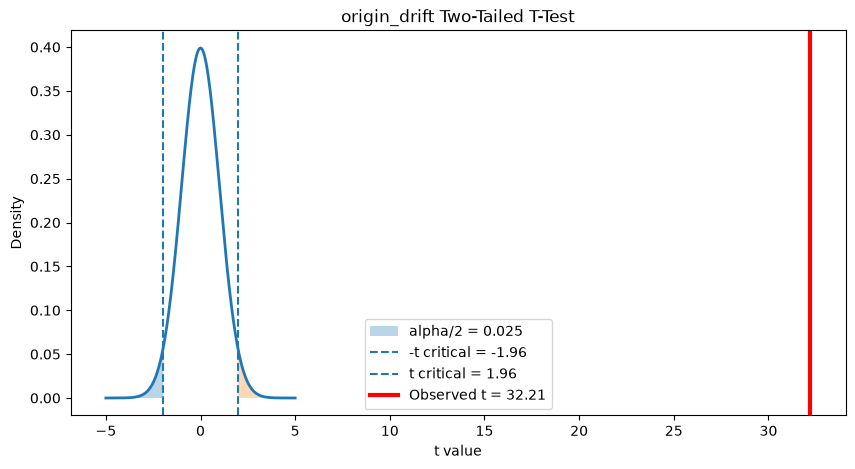

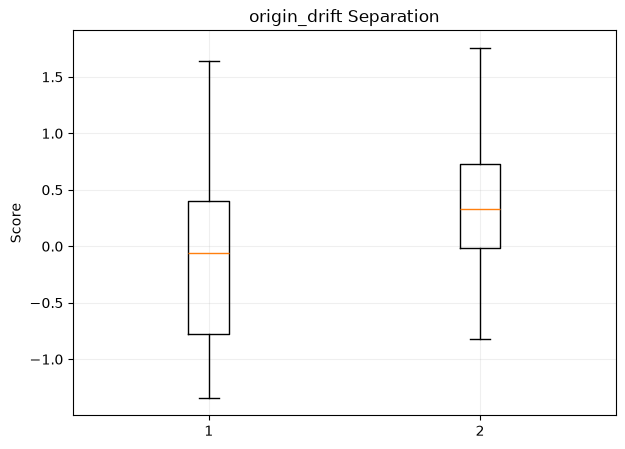

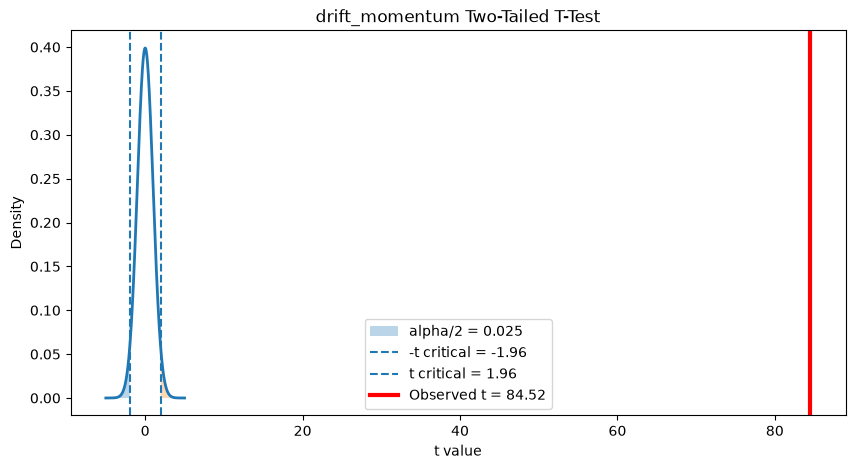

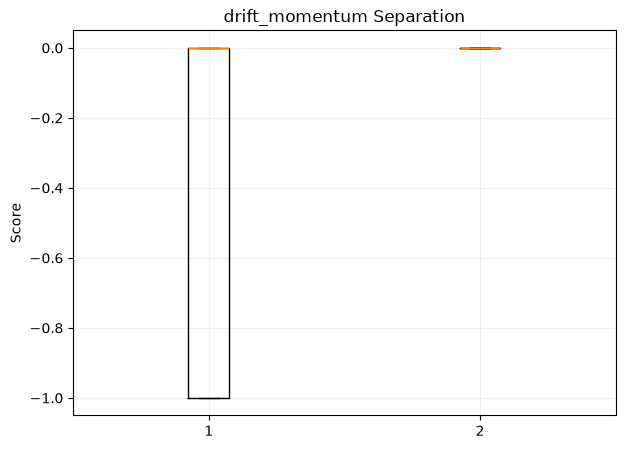

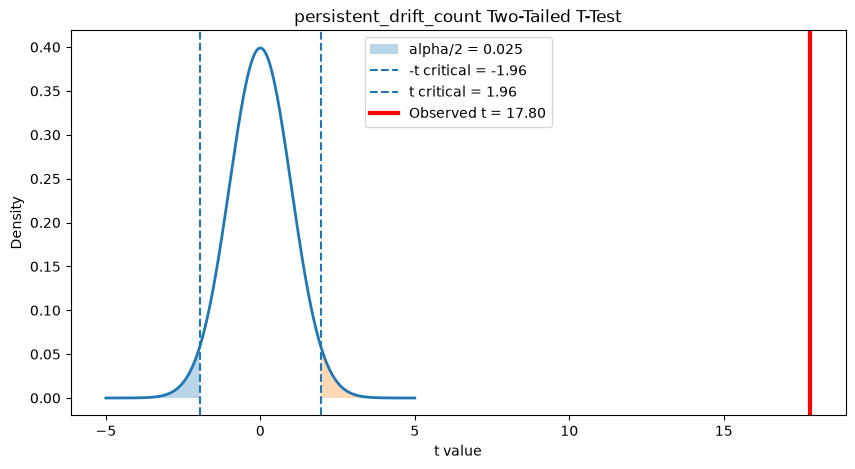

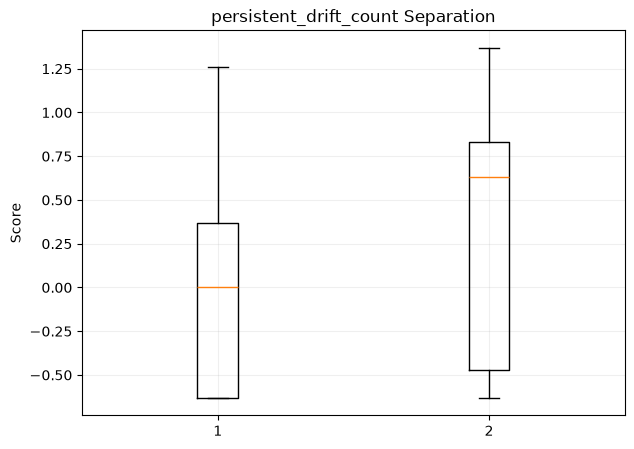

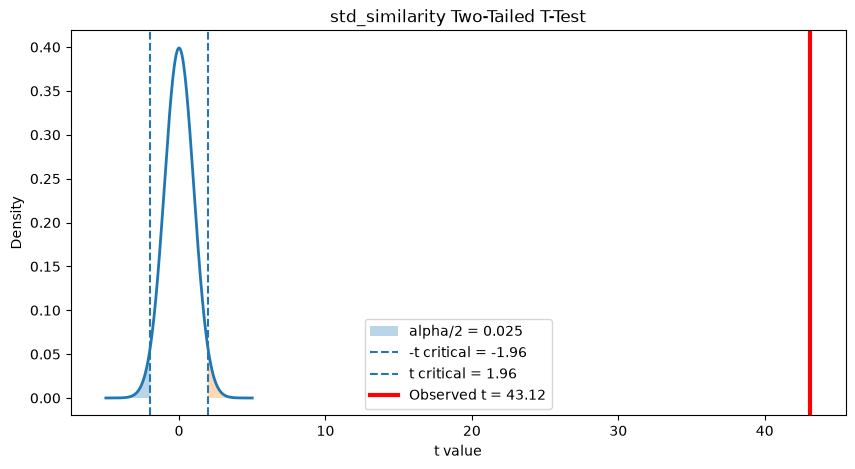

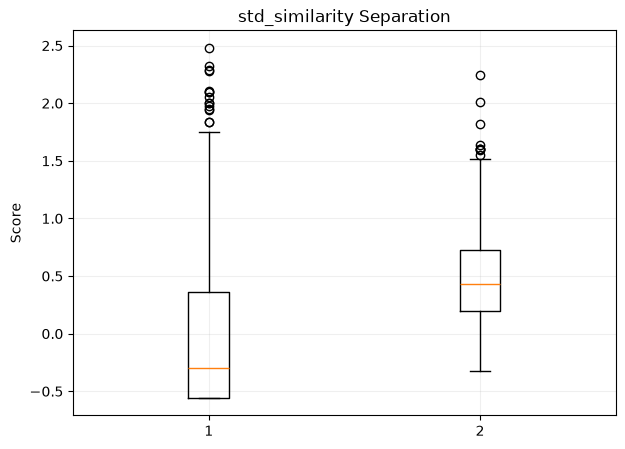

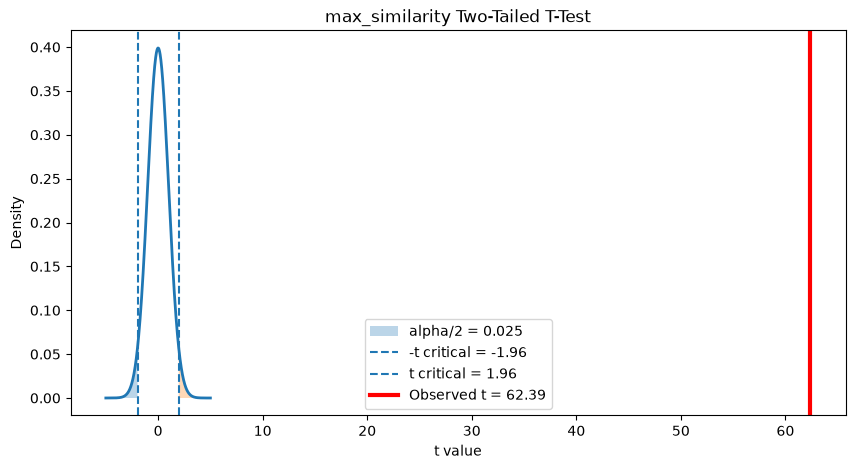

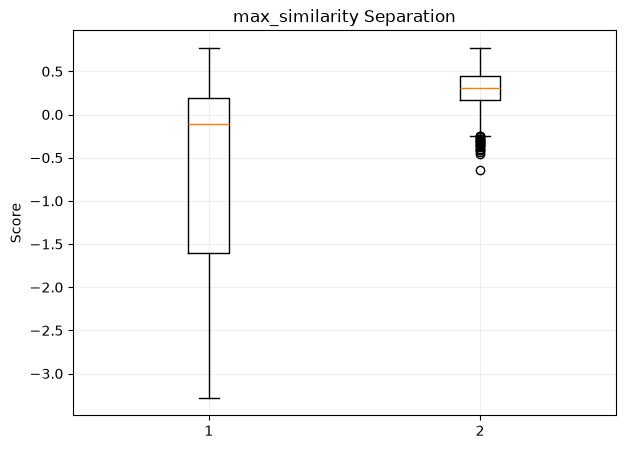

In [19]:

for feature in results_df_two_sample["feature"][:5]:
        
    scores = df[feature].values  
    labels = df["label"].values
    
    result = results_df_two_sample[results_df_two_sample["feature"] == feature].iloc[0]

    t_stat = result["t_stat"]
    p_value = result["p_value"]
    df_t = result["df"]
    

    plot_hypothesis_test(
    t_stat=t_stat,
    df=df_t,
    alpha=0.05,
    title=f"{feature} Two-Tailed T-Test"
    )

    plot_box_separation(
        scores,
        labels,
        class_names=("Safe", "Adversarial"),
        title=f"{feature} Separation"
    )

In [20]:
results_df_two_sample['ci_lower'] = results_df_two_sample['ci'].apply(lambda x: x[0])
results_df_two_sample['ci_upper'] = results_df_two_sample['ci'].apply(lambda x: x[1])

results_df_two_sample = results_df_two_sample.drop('ci', axis=1)

results_df_two_sample.to_csv("./data/two_sample_test_results.csv", index=False)


In [21]:
import json

results_json = []
for result in results_df_bootstrap_test.to_dict(orient="records"):
    results_json.append({
        "feature": result["feature"],
        "difference": float(result["difference"]),
        "ci_lower": float(result["ci_lower"]),
        "ci_upper": float(result["ci_upper"]),
        "significant": bool(result["significant"]),
        "bootstrap_diffs": result["bootstrap_diffs"]
    })

with open("./data/bootstrap_test_results.json", "w") as f:
    json.dump(results_json, f)

